# Default eCAT Analysis Template

Copy this notebook when starting a new electrochemistry analysis. Edit the paths and option dictionaries in **User Inputs**, then run top to bottom.

The template uses the packaged Fe/PhOH CV dataset by default so it runs immediately. Replace `DATA_DIR` or `SINGLE_FILE` with your own exported text data when starting a real project. The cells are intentionally compact: this is the notebook you copy after learning the details in notebooks 00-07.

## Setup

Import eCAT from the local `src` folder, create an export folder, apply a plotting style, and set the default plot convention for the session.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent


def display_path(path):
    path = Path(path)
    try:
        return str(path.resolve().relative_to(ROOT.resolve()))
    except ValueError:
        return path.name

SRC = str(ROOT / "src")
if SRC in sys.path:
    sys.path.remove(SRC)
sys.path.insert(0, SRC)

import ecat as e

e.plotting_style("notebook")
e.set_defaults("plot convention", "US")  # use "EU" if your lab plots cathodic current downward

EXPORT_DIR = ROOT / "notebooks" / "_outputs" / "template_run"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

print("eCAT version:", getattr(e, "__version__", "unknown"))
print("Export folder:", display_path(EXPORT_DIR))

eCAT version: 0.1.0b2
Export folder: notebooks/_outputs/template_run


## User Inputs

Replace these paths and loading options for your own project. Absolute paths are safest when your data live outside this repository.

- macOS/Linux example: `Path.home() / "Documents" / "Electrochemistry" / "CV" / "example_dataset"`
- Windows example: `Path.home() / "Documents" / "Electrochemistry" / "CV" / "example_dataset"`

`DATA_DIR` points to a folder for `e.get_data()`. `SINGLE_FILE` is optional, but useful when you want to inspect one representative file before loading the full folder.

In [2]:
# Replace these for your own project.
DATA_DIR = ROOT / "examples" / "data" / "fe_phoh_cv"
SINGLE_FILE = DATA_DIR / "MeCN_Ar_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_-1.2_to_1V_100mVs.txt"
EXPORT_DIR = ROOT / "notebooks" / "_outputs" / "template_run"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

LOAD_OPTIONS = {
    "folder path": str(DATA_DIR),
    "delimiter": ",",
    "decimal": ".",
    "columns": 3,
    "software": "CH",
    "print": True,
    "troubleshoot": False,
    "recursive search": False,
    "name alterations": {"Fe-tpyPY2Me": "[Fe]"},
    "pretty print": True,

    "reference mode": "keyword",
    "reference keywords": None,
    "reference keyword": "Fc",
    "reference file": None,
    "reference map": {12: 11},  # sample-data fix: use the 1 M PhOH reference for the 2.8 M PhOH trace
    "reference offset": None,
    "reference guess": 0.4,
    "reference label": "Fc/Fc+",
    "allow self reference": True,

    "compounds": None,
    "gas": None,
    "solvent": None,
    "temperature": 298,
    "electrode diameter": 0.3,
    "electrode area": None,
    "invert current": False,
}

SCAN_RATE_FILTER = {"gas": "Ar", "compounds": "[Fe]", "scan window": [-1.7, 1], "segments": 3}
CO2_FILTER = {"gas": "CO2", "segments": 3}
PHOH_FILTER = {"compounds": "PhOH"}

## Discover Help

Use `describe_options()` for eCAT option dictionaries, and Python `help()` for function signatures, docstrings, and examples. The option tables are long, so this template previews the first few rows with `.head()`.

In [3]:
e.describe_options("get_data", {"print": False, "return": True}).head()

,Category,Option,Default,Type,Choices,Description
0,Data/input,columns,3,int,,Number of columns expected in imported data fi...
1,Data/input,compounds,None,object or None,,Compound names associated with the electrochem...
2,Data/input,custom reader,None,object or None,,User-provided file reader for custom import fo...
3,Data/input,decimal,.,str,,Decimal separator used in imported text files.
4,Data/input,delimiter,",",str,,Column delimiter used in imported text files.


In [4]:
e.describe_options("multiplot", {"print": False, "return": True}).head()
help(e.get_data)

Help on function get_data in module ecat.io:

get_data(options={})
    Read electrochemistry text files from a folder into eCAT objects.

    Parameters
    ----------
    options : dict or ImportOptions, optional
        Import, parsing, sorting, and reference-shift options. See ``e.describe_options("get_data")``.

    Returns
    -------
    list of echem
        Imported CV, DPV, CA, CP, CPE, or generic electrochemistry objects.

    Examples
    --------
    >>> cvs = e.get_data({"folder path": folder, "reference mode": "keyword"})



## Load And Inspect

Load one file first when you want a quick sanity check, then load the full folder. Use `e.show()` rather than building one-off metadata tables.

In [5]:
cv = e.echem.from_file(str(SINGLE_FILE), LOAD_OPTIONS)
e.show(cv)

,Metric,Value
0,Name,MeCN_Ar_0.1MTBAPF6_3mMFc_1mM[Fe]_-1.2_to_1V_100mVs
1,Timestamp,2026-05-07 14:42:19
2,Creation Time,2026-06-08 12:16:55.081368
3,Modification Time,2026-06-08 12:16:55.082093
4,IR Comp Resistance,132 ohm
5,IR Uncomp Resistance,0 ohm
6,IR Comp Percent,100 %
7,Solvent,MeCN
8,Gas,Ar
9,Compounds,"TBAPF6, Fc, [Fe]"


,Metric,Value
0,Name,MeCN_Ar_0.1MTBAPF6_3mMFc_1mM[Fe]_-1.2_to_1V_100mVs
1,Timestamp,2026-05-07 14:42:19
2,Creation Time,2026-06-08 12:16:55.081368
3,Modification Time,2026-06-08 12:16:55.082093
4,IR Comp Resistance,132 ohm
5,IR Uncomp Resistance,0 ohm
6,IR Comp Percent,100 %
7,Solvent,MeCN
8,Gas,Ar
9,Compounds,"TBAPF6, Fc, [Fe]"


In [6]:
cvs = e.get_data(LOAD_OPTIONS)
cvs = e.filter(cvs, {"segments": 3}, {"print": False})
e.show(cvs)

Searching exclusively through:
 examples/data/fe_phoh_cv
13 .txt files found.

Reference correction:
  Mode: keyword
  Keyword: Fc
  Guess: 0.4 V
  Folder reference: MeCN_Ar_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_-1.2_to_1V_100mVs.txt = 0.4665 V
  Usage:
    folder/ancestor reference: 3
    self-referenced successfully: 9
    explicit reference map: 1

[Conditions] Exp Type: CV, Solvent: MeCN, Compounds: 0.1 M TBAPF₆
[Reference] Label: Fc/Fc+


,Gas,Compounds,Scan Window,Scan Rate,Segments,Reference Shift,Reference Mode,Reference Source
[0],Ar,1 mM [Fe],"[-1.5, 1.5]",100 mV/s,9,0.467,folder,[2]
[1],Ar,,"[-1.2, 1]",100 mV/s,3,0.467,folder,[2]
[2],Ar,"3 mM Fc, 1 mM [Fe]","[-1.2, 1]",100 mV/s,3,0.467,folder,[2]
[3],Ar,"3 mM Fc, 1 mM [Fe]","[-1.7, 1]",100 mV/s,3,0.467,self,[3]
[4],Ar,"3 mM Fc, 1 mM [Fe]","[-1.7, 1]",25 mV/s,3,0.467,self,[4]
[5],Ar,"3 mM Fc, 1 mM [Fe]","[-1.7, 1]",500 mV/s,3,0.466,self,[5]
[6],Ar,"3 mM Fc, 1 mM [Fe]","[-1.7, 1]",1 V/s,3,0.466,self,[6]
[7],Ar,"3 mM Fc, 1 mM [Fe]","[-1.7, 1]",50 mV/s,3,0.467,self,[7]
[8],CO2,"3 mM Fc, 1 mM [Fe]","[-1.2, 1]",100 mV/s,3,0.467,self,[8]
[9],CO2,"3 mM Fc, 1 mM [Fe], 100 mM PhOH","[-1.2, 1]",100 mV/s,3,0.466,self,[9]


[Conditions] Exp Type: CV, Solvent: MeCN, Compounds: 0.1 M TBAPF₆, Segments: 3, IR Comp Percent: 100 %


,Gas,Compounds,Scan Window,Scan Rate
[0],Ar,,"[-1.2, 1]",100 mV/s
[1],Ar,"3 mM Fc, 1 mM [Fe]","[-1.2, 1]",100 mV/s
[2],Ar,"3 mM Fc, 1 mM [Fe]","[-1.7, 1]",100 mV/s
[3],Ar,"3 mM Fc, 1 mM [Fe]","[-1.7, 1]",25 mV/s
[4],Ar,"3 mM Fc, 1 mM [Fe]","[-1.7, 1]",500 mV/s
[5],Ar,"3 mM Fc, 1 mM [Fe]","[-1.7, 1]",1 V/s
[6],Ar,"3 mM Fc, 1 mM [Fe]","[-1.7, 1]",50 mV/s
[7],CO2,"3 mM Fc, 1 mM [Fe]","[-1.2, 1]",100 mV/s
[8],CO2,"3 mM Fc, 1 mM [Fe], 100 mM PhOH","[-1.2, 1]",100 mV/s
[9],CO2,"3 mM Fc, 1 mM [Fe], 560 mM PhOH","[-1.2, 1]",100 mV/s


## Select Working Series

The rest of the template creates a scan-rate series for redox analysis and a CO2/PhOH titration series for catalytic analysis.

In [7]:
scan_series = e.filter(cvs, SCAN_RATE_FILTER, {"logic": "AND", "print": False})
scan_series = e.sort(scan_series, "scan rate", {"print": False})

co2_cvs = e.filter(cvs, CO2_FILTER, {"print": False})
co2_only = e.filter(co2_cvs, PHOH_FILTER, {"mode": "exclude", "print": False})[0]
phoh_co2 = e.filter(co2_cvs, PHOH_FILTER, {"print": False})

cv = scan_series[0]
e.show(scan_series)
e.show(phoh_co2)

[Conditions] Exp Type: CV, Solvent: MeCN, Gas: Ar, Compounds: 0.1 M TBAPF₆, 3 mM Fc, 1 mM [Fe], Scan Window: [-1.7, 1], Segments: 3, IR Comp Percent: 100 %


,Scan Rate
[0],25 mV/s
[1],50 mV/s
[2],100 mV/s
[3],500 mV/s
[4],1 V/s


[Conditions] Exp Type: CV, Solvent: MeCN, Gas: CO₂, Compounds: 0.1 M TBAPF₆, 3 mM Fc, 1 mM [Fe], Scan Window: [-1.2, 1], Scan Rate: 100 mV/s, Segments: 3, IR Comp Percent: 100 %


,Compounds
[0],100 mM PhOH
[1],560 mM PhOH
[2],1 M PhOH
[3],2.8 M PhOH


## Plot

The option dictionaries below start from eCAT's current defaults and expose the full option set. Change values here when you want a consistent plotting style for the whole section. `MULTIPLOT_OPTIONS` adds label alterations because this sample dataset has a long catalyst name.


In [8]:
PLOT_OPTIONS = e.PlotOptions.from_options().to_legacy_dict()

MULTIPLOT_OPTIONS = e.MultiplotOptions.from_options().to_legacy_dict()
MULTIPLOT_OPTIONS["label alterations"] = {"3 mM Fc": "[Fc]", "1 mM [Fe]": "[Fe]"}


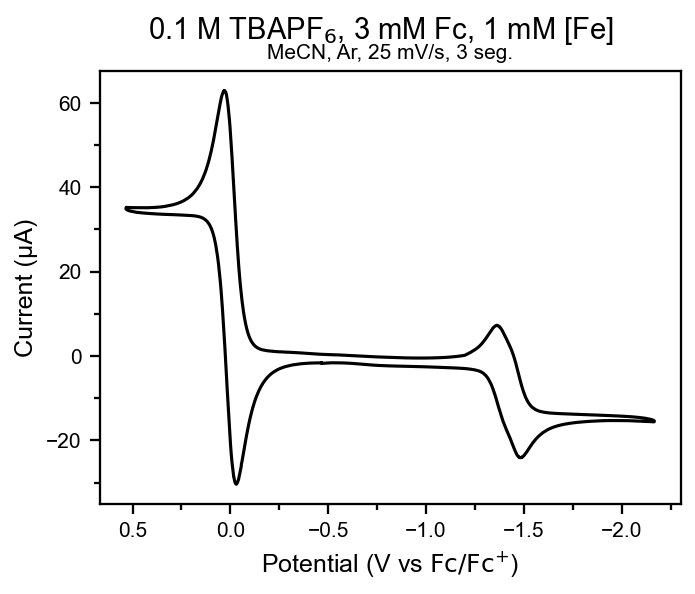

In [9]:
ax = cv.plot(PLOT_OPTIONS)
# ax.figure.savefig(EXPORT_DIR / "single_cv.png", dpi=300, bbox_inches="tight")

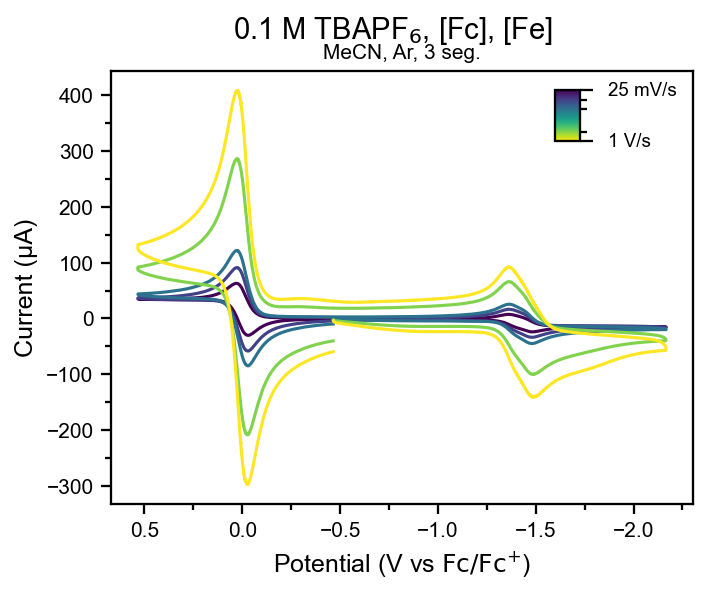

In [10]:
ax = e.multiplot(scan_series, MULTIPLOT_OPTIONS)
# ax.figure.savefig(EXPORT_DIR / "scan_rate_multiplot.png", dpi=300, bbox_inches="tight")

## Analyze A Scan-Rate Series

Use `sevcik_analysis()` when peak current should scale with scan rate, and `fit_peak_potential()` when you want to track how feature positions shift across the same series. Keep the analysis assumptions close to the cells that use them.

In [11]:
SEVCIK_OPTIONS = {
    "plot all": True,
    "segments": [1, 2],
    "guess potential": -1.5,
    "num electrons": 1,
    "scan dependence": 0.5,
    "plot fit": True,
    "print": True,
}

FIT_PEAK_POTENTIAL_OPTIONS = {
    "plot all": True,
    "plot": True,
    "print": True,
    "segments": [1, 2],
    "guess potential": -1.5,
    "follow E1/2": True,
    "plot fit": True,
}

[Conditions] Exp Type: CV, Solvent: MeCN, Gas: Ar, Compounds: 0.1 M TBAPF₆, 3 mM Fc, 1 mM [Fe], Scan Window: [-1.7, 1], Segments: 3, IR Comp Percent: 100 %


,Plot Label,Scan Rate
[0],25 mV/s,25 mV/s
[1],50 mV/s,50 mV/s
[2],100 mV/s,100 mV/s
[3],500 mV/s,500 mV/s
[4],1 V/s,1 V/s


Sevcik Analysis Summary:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

,Parameter,Value
0,n,1
1,T,298 K
2,S,0.07069 cm^2
3,C*,1e-06 mol/cm^3
4,Scan dependence,0.5


Sevcik Fit Results:


,series,Fit,R2,RMSE,Fit Points,fit x min,fit x max,Diffusion Coefficient
0,Seg 1,y = -113.9x -4.129,0.999277,0.985925,5,0.158114,1.0,3.590e-05 cm^2/s
1,Seg 2,y = 104.3x +4.974,0.999320,0.875479,5,0.158114,1.0,3.010e-05 cm^2/s


,series,Fit,R2,RMSE,Fit Points,fit x min,fit x max,Diffusion Coefficient
0,Seg 1,y = -113.9x -4.129,0.999277,0.985925,5,0.158114,1.0,3.590e-05 cm^2/s
1,Seg 2,y = 104.3x +4.974,0.999320,0.875479,5,0.158114,1.0,3.010e-05 cm^2/s


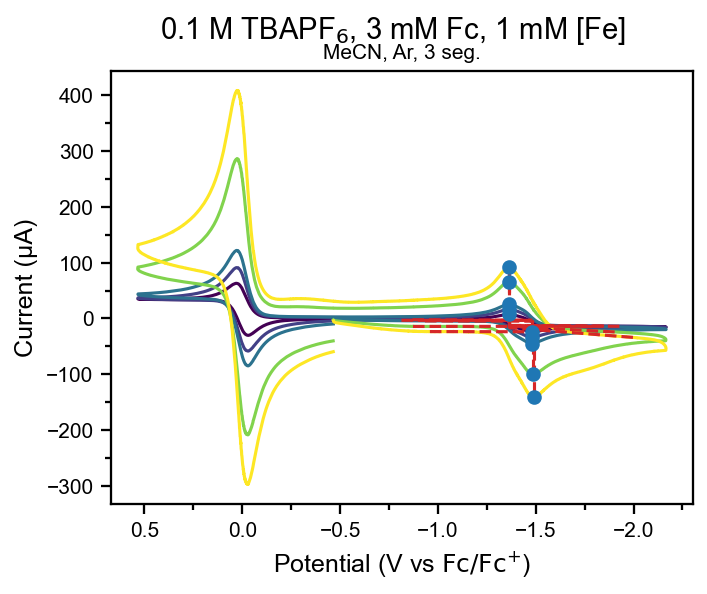

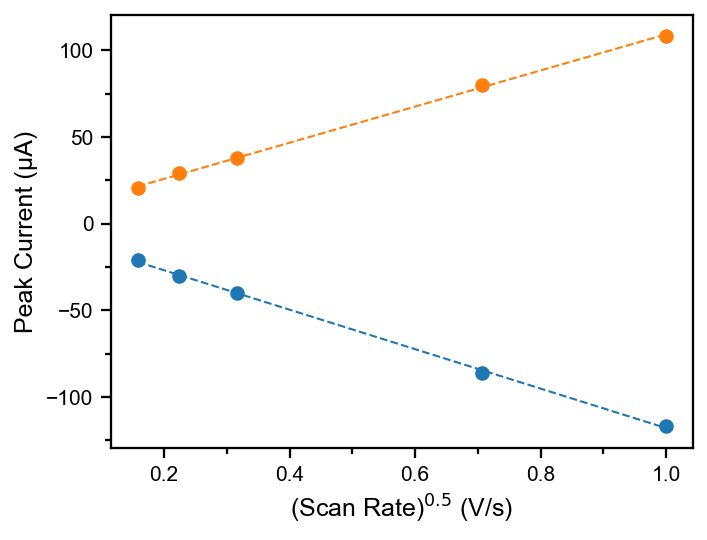

In [12]:
sevcik = e.sevcik_analysis(scan_series, SEVCIK_OPTIONS)
sevcik.fit_table

[Conditions] Exp Type: CV, Solvent: MeCN, Gas: Ar, Compounds: 0.1 M TBAPF₆, 3 mM Fc, 1 mM [Fe], Scan Window: [-1.7, 1], Segments: 3, IR Comp Percent: 100 %


,Plot Label,Scan Rate
[0],25 mV/s,25 mV/s
[1],50 mV/s,50 mV/s
[2],100 mV/s,100 mV/s
[3],500 mV/s,500 mV/s
[4],1 V/s,1 V/s


Fit Model:


,Field,Seg 1 Ep,Seg 2 Ep,Seg 1-2 E1/2
0,Model,linear,linear,linear
1,Equation,y = m x + b,y = m x + b,y = m x + b
2,Residual,direct,direct,direct
3,X Range,-1.60206 to 0,-1.60206 to 0,-1.60206 to 0
4,Fit Points,5,5,5
5,R²,0.748847,0.155664,0.934232
6,RMSE,0.00170391,0.00102322,0.00044861
7,m,-0.00488344 ± 0.00163282,-0.000729215 ± 0.000980519,-0.00280633 ± 0.000429891
8,b,-1.48791 ± 0.00168898,-1.36421 ± 0.00101425,-1.42606 ± 0.000444678


,name,Scan Rate (V/s),x transformed,$\log_{10}$(Scan Rate / V/s),Seg 1 Ep (V),Seg 2 Ep (V),Seg 1-2 E1/2 (V),Seg 1-2 ΔE (V),Seg 1 Ep y raw,Seg 1 Ep y adjusted,...,Seg 2 Ep y raw,Seg 2 Ep y adjusted,Seg 2 Ep y transformed,Seg 2 Ep y0,Seg 2 Ep y mode,Seg 1-2 E1/2 y raw,Seg 1-2 E1/2 y adjusted,Seg 1-2 E1/2 y transformed,Seg 1-2 E1/2 y0,Seg 1-2 E1/2 y mode
0,MeCN_Ar_0.1MTBAPF6_3mMFc_1mM[Fe]_-1.7_to_1V_25mVs,0.025,-1.60206,-1.60206,-1.4825,-1.3615,-1.4220,0.121,-1.4825,-1.4825,...,-1.3615,-1.3615,-1.3615,-1.3615,raw,-1.4220,-1.4220,-1.4220,-1.422,raw
1,MeCN_Ar_0.1MTBAPF6_3mMFc_1mM[Fe]_-1.7_to_1V_50mVs,0.050,-1.30103,-1.30103,-1.4805,-1.3645,-1.4225,0.116,-1.4805,-1.4805,...,-1.3645,-1.3645,-1.3645,-1.3615,raw,-1.4225,-1.4225,-1.4225,-1.422,raw
2,MeCN_Ar_0.1MTBAPF6_3mMFc_1mM[Fe]_-1.7_to_1V_10...,0.100,-1.00000,-1.00000,-1.4805,-1.3645,-1.4225,0.116,-1.4805,-1.4805,...,-1.3645,-1.3645,-1.3645,-1.3615,raw,-1.4225,-1.4225,-1.4225,-1.422,raw
3,MeCN_Ar_0.1MTBAPF6_3mMFc_1mM[Fe]_-1.7_to_1V_50...,0.500,-0.30103,-0.30103,-1.4865,-1.3635,-1.4250,0.123,-1.4865,-1.4865,...,-1.3635,-1.3635,-1.3635,-1.3615,raw,-1.4250,-1.4250,-1.4250,-1.422,raw
4,MeCN_Ar_0.1MTBAPF6_3mMFc_1mM[Fe]_-1.7_to_1V_1Vs,1.000,0.00000,0.00000,-1.4890,-1.3640,-1.4265,0.125,-1.4890,-1.4890,...,-1.3640,-1.3640,-1.3640,-1.3615,raw,-1.4265,-1.4265,-1.4265,-1.422,raw


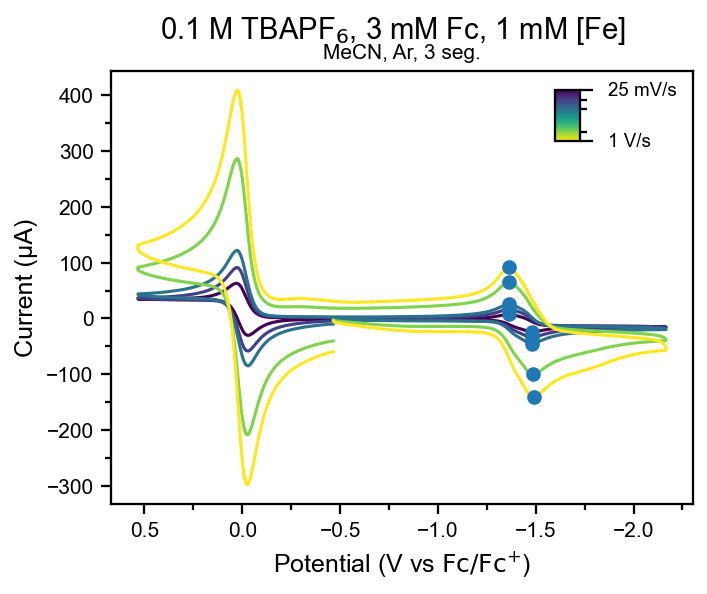

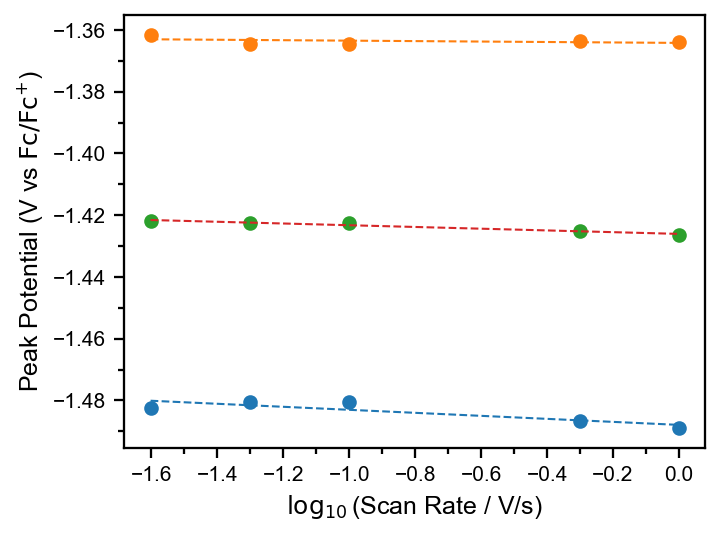

In [13]:
ep_fit = e.fit_peak_potential(scan_series, FIT_PEAK_POTENTIAL_OPTIONS)
ep_fit.table

## Catalytic Workflow: FOWA And Rate Fit

Use FOWA to extract kinetic information from the foot of a catalytic wave, then pass the result table directly into `fit_rate()` for a concentration-order style fit. Replace the redox potential, fit range, and non-catalytic reference before interpreting real data.

In [14]:
FOWA_OPTIONS = {
    "plot all": True,
    "non-catalytic cv": co2_only,
    "redox mode": "manual",
    "redox potential": -1.47,
    "fit basis": "y",
    "fit range": [0.1, 0.5],
    "diagnostic y axis": "i/ip0",
    "min fit points": 50,
    "min r2": 0.95,
    "print": True,
}

FIT_RATE_OPTIONS = {
    "metric": "kobs",
    "species": "PhOH",
    "transform mode": "log-log",
    "plot": True,
    "print": True,
}

[Conditions] Exp Type: CV, Solvent: MeCN, Gas: CO₂, Compounds: 0.1 M TBAPF₆, 3 mM Fc, 1 mM [Fe], Scan Window: [-1.2, 1], Scan Rate: 100 mV/s, Segments: 3, IR Comp Percent: 100 %

### FOWA Summary ###


,Field,Value
0,Reference CV,MeCN_CO2_0.1MTBAPF6_3mMFc_1mM[Fe]_-1.2_to_1V_100mVs
1,ip0 Source,MeCN_CO2_0.1MTBAPF6_3mMFc_1mM[Fe]_-1.2_to_1V_100mVs
2,Redox Source,manual (-1.47 V)
3,Redox Potential,-1.47
4,Reference Ep,-1.478
5,Segment,1
6,Background Correction,tangent
7,Fit Range,"[0.1, 0.5]"
8,Mechanism,EC'
9,ip0,-5.117e-05


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

,Compounds,Background Tangent,Wave Range,Fit Points,FOWA Fit,R2,Status,kobs
0,100 mM PhOH,y = 2.6071e-06x - 2.78394e-06,"[-1.213, -1.521]",67,y = 30.2296x + 0.0899852,0.983259,ok,708.810860
1,560 mM PhOH,y = 2.36291e-06x - 3.28446e-06,"[-1.21, -1.536]",66,y = 48.4845x + 0.0799615,0.990976,ok,1823.350532
2,1 M PhOH,y = 3.0778e-06x - 2.1115e-06,"[-1.2145, -1.5745]",60,y = 50.0748x + 0.0656466,0.995336,ok,1944.928628
3,2.8 M PhOH,y = -3.52989e-07x - 4.25457e-06,"[-1.2125, -1.6685]",57,y = 60.7236x + 0.0655418,0.986015,ok,2860.087456


,Compounds,Background Tangent,Wave Range,Fit Points,FOWA Fit,R2,Status,kobs
0,100 mM PhOH,y = 2.6071e-06x - 2.78394e-06,"[-1.213, -1.521]",67,y = 30.2296x + 0.0899852,0.983259,ok,708.810860
1,560 mM PhOH,y = 2.36291e-06x - 3.28446e-06,"[-1.21, -1.536]",66,y = 48.4845x + 0.0799615,0.990976,ok,1823.350532
2,1 M PhOH,y = 3.0778e-06x - 2.1115e-06,"[-1.2145, -1.5745]",60,y = 50.0748x + 0.0656466,0.995336,ok,1944.928628
3,2.8 M PhOH,y = -3.52989e-07x - 4.25457e-06,"[-1.2125, -1.6685]",57,y = 60.7236x + 0.0655418,0.986015,ok,2860.087456


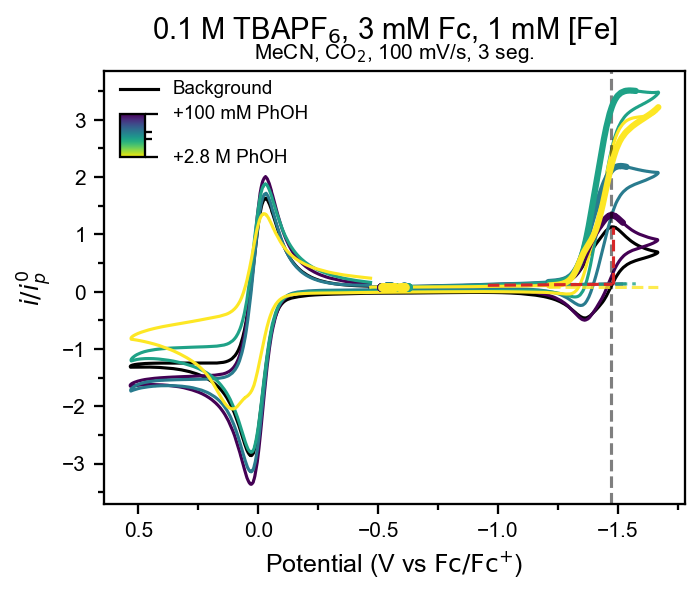

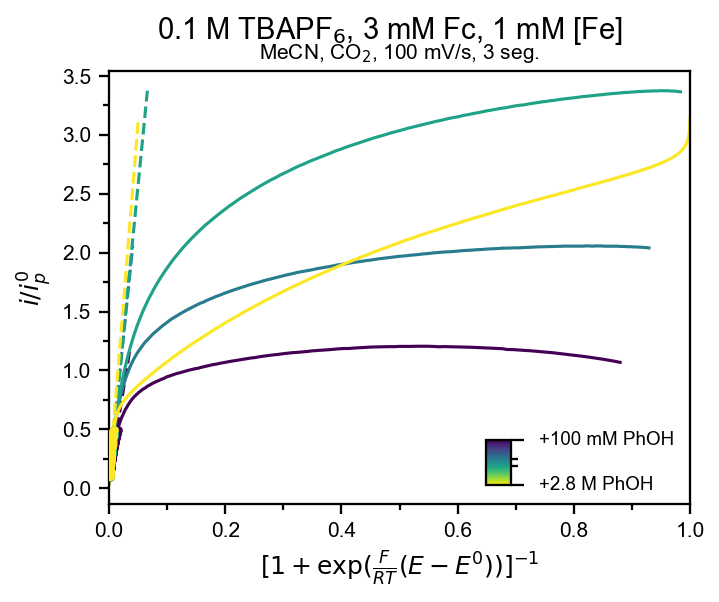

In [15]:
fowa_table = e.fowa(phoh_co2, FOWA_OPTIONS)
fowa_table

Fit Model:


,Field,Value
0,Model,linear
1,Equation,y = m x + b
2,Residual,direct
3,X Range,-1 to 0.4472
4,Fit Points,4
5,R²,0.9678
6,RMSE,0.04002
7,m,0.4178 ± 0.05393
8,b,3.298 ± 0.03031


,Compounds,Reference CV,ip0 Source,Redox Source,Reference Ep,Redox Mode,Redox Delta E,Redox Potential,Catalytic Ecat/2,Ecat/2 - E1/2,...,y label,y raw,y adjusted,y0,y mode,x transformed,y transformed,x transform,y transform,y transform note
0,100 mM PhOH,MeCN_CO2_0.1MTBAPF6_3mMFc_1mM[Fe]_-1.2_to_1V_1...,MeCN_CO2_0.1MTBAPF6_3mMFc_1mM[Fe]_-1.2_to_1V_1...,manual,-1.478,manual,None,-1.47,None,None,...,kobs,708.810860,708.810860,708.81086,raw,-1.000000,2.850530,log10,log10,
1,560 mM PhOH,MeCN_CO2_0.1MTBAPF6_3mMFc_1mM[Fe]_-1.2_to_1V_1...,MeCN_CO2_0.1MTBAPF6_3mMFc_1mM[Fe]_-1.2_to_1V_1...,manual,-1.478,manual,None,-1.47,None,None,...,kobs,1823.350532,1823.350532,708.81086,raw,-0.251812,3.260870,log10,log10,
2,1 M PhOH,MeCN_CO2_0.1MTBAPF6_3mMFc_1mM[Fe]_-1.2_to_1V_1...,MeCN_CO2_0.1MTBAPF6_3mMFc_1mM[Fe]_-1.2_to_1V_1...,manual,-1.478,manual,None,-1.47,None,None,...,kobs,1944.928628,1944.928628,708.81086,raw,0.000000,3.288904,log10,log10,
3,2.8 M PhOH,MeCN_CO2_0.1MTBAPF6_3mMFc_1mM[Fe]_-1.2_to_1V_1...,MeCN_CO2_0.1MTBAPF6_3mMFc_1mM[Fe]_-1.2_to_1V_1...,manual,-1.478,manual,None,-1.47,None,None,...,kobs,2860.087456,2860.087456,708.81086,raw,0.447158,3.456379,log10,log10,


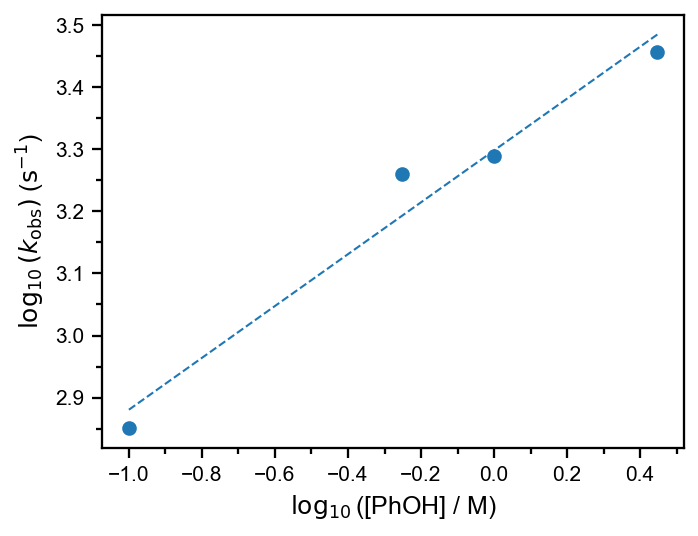

In [16]:
fowa_rate_fit = e.fit_rate(fowa_table, FIT_RATE_OPTIONS)
fowa_rate_fit.table

## Export

Save a polished figure and a processed data table into `EXPORT_DIR`. Adjust filenames so each analysis run is traceable.

In [17]:
fig_path = EXPORT_DIR / "scan_rate_overlay.png"
ax = e.multiplot(scan_series, MULTIPLOT_OPTIONS)
ax.figure.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.close(ax.figure)

exported = e.save_data(scan_series, {
    "folder path": str(EXPORT_DIR),
    "file name": "scan_rate_series",
    "y unit": "uA",
})

print("Saved:", display_path(fig_path))
print("Saved:", display_path(EXPORT_DIR / "scan_rate_series.csv"))
exported.head()

Saved 5 echem objects to:
notebooks/_outputs/template_run/scan_rate_series.csv
Saved: notebooks/_outputs/template_run/scan_rate_overlay.png
Saved: notebooks/_outputs/template_run/scan_rate_series.csv


MeCN_Ar_0.1MTBAPF6_3mMFc_1mM[Fe]_-1.7_to_1V_25mVs               \
                                     Potential (uA) Current (uA)   
0                                               0.0       -1.715   
1                                           -1000.0       -1.749   
2                                           -2000.0       -1.755   
3                                           -3000.0       -1.757   
4                                           -4000.0       -1.759   

  MeCN_Ar_0.1MTBAPF6_3mMFc_1mM[Fe]_-1.7_to_1V_50mVs               \
                                     Potential (uA) Current (uA)   
0                                               0.0       -2.776   
1                                           -1000.0       -2.868   
2                                           -2000.0       -2.898   
3                                           -3000.0       -2.909   
4                                           -4000.0       -2.926   

  MeCN_Ar_0.1MTBAPF6_3mMFc_1mM[Fe]_-1.7_to_1V_100mVs               \
                                      Potential (uA) Current (uA)   
0                                                0.0       -1.781   
1                                            -1000.0       -1.912   
2                                            -2000.0       -1.952   
3                                            -3000.0       -1.986   
4                                            -4000.0       -2.021   

  MeCN_Ar_0.1MTBAPF6_3mMFc_1mM[Fe]_-1.7_to_1V_500mVs               \
                                      Potential (uA) Current (uA)   
0                                                0.0       -2.709   
1                                            -1000.0       -3.196   
2                                            -2000.0       -3.501   
3                                            -3000.0       -3.592   
4                                            -4000.0       -3.684   

  MeCN_Ar_0.1MTBAPF6_3mMFc_1mM[Fe]_-1.7_to_1V_1Vs               
                                   Potential (uA) Current (uA)  
0                                             0.0       -4.415  
1                                         -1000.0       -5.602  
2                                         -2000.0       -6.029  
3                                         -3000.0       -6.272  
4                                         -4000.0       -6.546

## Notes For Reproducibility

When sharing a notebook or reporting a problem, include the eCAT version, the data filename(s), the instrument/export format if known, the relevant option dictionaries, and the smallest cell that reproduces the behavior.